# ML Regression from Scratch - Notebook 05 - Logistic Regression (Single Feature: TotalHours)

**Goal:** predict whether a student **passes** the capstone using a
**single feature**, `TotalHours` (total study hours), with binary logistic
regression built entirely from scratch - sigmoid, cross-entropy loss,
gradient descent, no scikit-learn.


We will:
1. Build the binary label at the 50-mark cut-off and check class balance
2. Implement `sigmoid`, `compute_logistic_cost`, `compute_logistic_gradients`,
   `logistic_gradient_descent`, `predict_proba`, `predict_class`
3. Train on the single feature, visualize the fitted sigmoid curve and
   the decision boundary
4. Evaluate with a confusion matrix, accuracy, precision, recall, F1

In [3]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

np.random.seed(42)

## 1. Load data & build the binary label

`Pass = 1` if `CapstoneScore >= 50`, else `Fail = 0`.

In [4]:
df = pd.read_csv('student scores.csv')
df = df[df['CourseName'] == 'Foundations of ML'].reset_index(drop=True)

PASS_MARK = 50
df['Pass'] = (df['CapstoneScore'] >= PASS_MARK).astype(int)

print(f"Rows: {len(df)}")
print(df['Pass'].value_counts().rename({0: 'Fail (0)', 1: 'Pass (1)'}))
print(f"Pass rate at cut-off {PASS_MARK}: {df['Pass'].mean():.1%}")

Rows: 72
Pass
Pass (1)    42
Fail (0)    30
Name: count, dtype: int64
Pass rate at cut-off 50: 58.3%


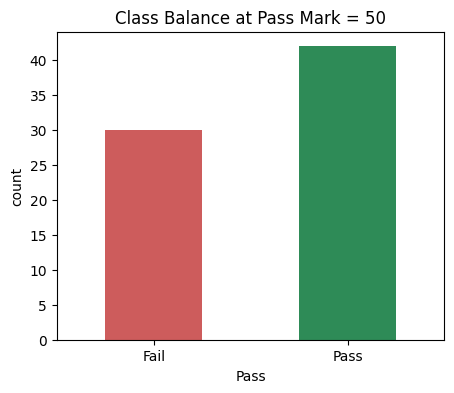

In [5]:
plt.figure(figsize=(5, 4))
df['Pass'].value_counts().sort_index().plot(kind='bar', color=['indianred', 'seagreen'])
plt.xticks([0, 1], ['Fail', 'Pass'], rotation=0)
plt.ylabel('count')
plt.title(f'Class Balance at Pass Mark = {PASS_MARK}')
plt.show()

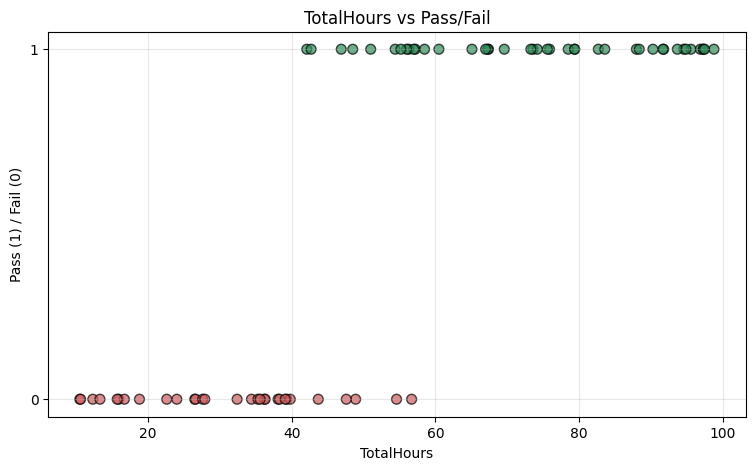

In [6]:
plt.figure(figsize=(9, 5))
colors = df['Pass'].map({0: 'indianred', 1: 'seagreen'})
plt.scatter(df['TotalHours'], df['Pass'], c=colors, s=50, alpha=0.7, edgecolor='k')
plt.xlabel('TotalHours')
plt.ylabel('Pass (1) / Fail (0)')
plt.title('TotalHours vs Pass/Fail')
plt.yticks([0, 1])
plt.grid(alpha=0.3)
plt.show()

## 2. Train/test split & feature scaling

Same shuffle-split-then-standardize pattern as the earlier notebooks,
using a **stratified** split from the start — the multi-feature logistic
regression notebook showed that a plain random split can accidentally
leave one class out of the test set entirely, so we build the safer
version in directly this time.

In [7]:
def stratified_train_test_split(X, y, test_size=0.2, seed=42):
    """Split each class separately (80/20), then recombine, so both
    train and test preserve the original class balance."""
    rng = np.random.RandomState(seed)
    y = np.asarray(y)
    train_idx_parts, test_idx_parts = [], []

    for class_value in np.unique(y):
        class_idx = np.where(y == class_value)[0]
        shuffled = rng.permutation(class_idx)
        n_test = max(1, int(len(shuffled) * test_size))
        test_idx_parts.append(shuffled[:n_test])
        train_idx_parts.append(shuffled[n_test:])

    train_idx = rng.permutation(np.concatenate(train_idx_parts))
    test_idx = rng.permutation(np.concatenate(test_idx_parts))
    return X[train_idx], X[test_idx], y[train_idx], y[test_idx]


def standardize_features(X, mu=None, sigma=None):
    if mu is None or sigma is None:
        mu = X.mean(axis=0)
        sigma = X.std(axis=0)
    return (X - mu) / sigma, mu, sigma


def add_bias(X):
    return np.column_stack([np.ones(len(X)), X])


X = df[['TotalHours']].values.astype(float)   # keep as (m, 1) so the same matrix code works
y = df['Pass'].values.astype(float)

X_train, X_test, y_train, y_test = stratified_train_test_split(X, y, test_size=0.2, seed=42)

X_train_scaled, mu, sigma = standardize_features(X_train)
X_test_scaled, _, _ = standardize_features(X_test, mu, sigma)

X_train_design = add_bias(X_train_scaled)
X_test_design = add_bias(X_test_scaled)

print(f"Train: {X_train_design.shape}, Test: {X_test_design.shape}")
print(f"Train pass rate: {y_train.mean():.1%},  Test pass rate: {y_test.mean():.1%}")

Train: (58, 2), Test: (14, 2)
Train pass rate: 58.6%,  Test pass rate: 57.1%


## 3. The maths, from absolute basics

**Sigmoid** squashes any real number into a probability between 0 and 1:

$$\sigma(z) = \frac{1}{1 + e^{-z}}$$

**Hypothesis** for one feature:

$$h_\theta(x) = \sigma(\theta_0 + \theta_1 x)$$

**Cost — binary cross-entropy:**

$$J(\boldsymbol\theta) = -\frac{1}{m}\sum_{i=1}^{m}\Big[y_i\log h_\theta(x_i) + (1-y_i)\log(1-h_\theta(x_i))\Big]$$

**Gradient** (same clean vectorised form as the multi-feature case):

$$\nabla J(\boldsymbol\theta) = \frac{1}{m}X^\top(h_\theta(X)-\mathbf y)$$

**Update:** $\boldsymbol\theta := \boldsymbol\theta - \alpha\nabla J(\boldsymbol\theta)$.

### 3.1 `sigmoid`

In [8]:
def sigmoid(z):
    """Logistic sigmoid, elementwise. Clips z to avoid exp() overflow."""
    z = np.clip(z, -500, 500)
    return 1 / (1 + np.exp(-z))


print(f"sigmoid(0)   = {sigmoid(0):.4f}")
print(f"sigmoid(10)  = {sigmoid(10):.4f}")
print(f"sigmoid(-10) = {sigmoid(-10):.4f}")

sigmoid(0)   = 0.5000
sigmoid(10)  = 1.0000
sigmoid(-10) = 0.0000


### 3.2 `compute_logistic_cost`

In [9]:
def compute_logistic_cost(X_design, y, theta, eps=1e-15):
    """Binary cross-entropy cost. eps avoids log(0)."""
    m = len(y)
    h = sigmoid(X_design.dot(theta))
    h = np.clip(h, eps, 1 - eps)
    return -(1 / m) * np.sum(y * np.log(h) + (1 - y) * np.log(1 - h))


test_cost = compute_logistic_cost(X_train_design, y_train, theta=np.zeros(X_train_design.shape[1]))
print(f"Cost at theta=0 (should be close to ln(2) = 0.6931): {test_cost:.4f}")

Cost at theta=0 (should be close to ln(2) = 0.6931): 0.6931


### 3.3 `compute_logistic_gradients`

In [10]:
def compute_logistic_gradients(X_design, y, theta):
    """Vectorised gradient of the cross-entropy cost."""
    m = len(y)
    h = sigmoid(X_design.dot(theta))
    return (1 / m) * X_design.T.dot(h - y)


grad_test = compute_logistic_gradients(X_train_design, y_train, theta=np.zeros(X_train_design.shape[1]))
print(f"Gradient at theta=0: {grad_test.round(4)}")

Gradient at theta=0: [-0.0862 -0.3982]


### 3.4 `logistic_gradient_descent`

In [11]:
def logistic_gradient_descent(X_design, y, learning_rate, n_iterations=3000, theta_init=None):
    """Batch gradient descent for logistic regression."""
    n = X_design.shape[1]
    theta = np.zeros(n) if theta_init is None else theta_init
    cost_history = []

    for i in range(n_iterations):
        cost = compute_logistic_cost(X_design, y, theta)
        if not np.isfinite(cost):
            break
        cost_history.append(cost)
        theta = theta - learning_rate * compute_logistic_gradients(X_design, y, theta)

    return theta, cost_history

### 3.5 `predict_proba` and `predict_class`

In [12]:
def predict_proba(X_design, theta):
    """Predicted probability of Pass for each row."""
    return sigmoid(X_design.dot(theta))


def predict_class(X_design, theta, threshold=0.5):
    """Threshold predicted probabilities into hard 0/1 labels."""
    return (predict_proba(X_design, theta) >= threshold).astype(int)

## 4. Train the model

In [13]:
LEARNING_RATE = 0.5
N_ITERATIONS = 3000

theta, cost_history = logistic_gradient_descent(X_train_design, y_train, LEARNING_RATE, N_ITERATIONS)

print(f"Trained for {len(cost_history)} iterations")
print(f"Final training cost: {cost_history[-1]:.4f}")
print(f"Learned theta -> bias (theta_0) = {theta[0]:.4f}, TotalHours weight (theta_1) = {theta[1]:.4f}")

Trained for 3000 iterations
Final training cost: 0.1288
Learned theta -> bias (theta_0) = 3.3898, TotalHours weight (theta_1) = 8.9268


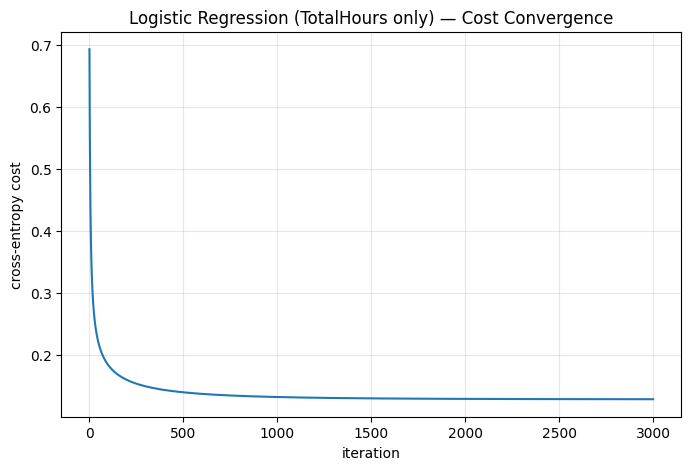

In [14]:
plt.figure(figsize=(8, 5))
plt.plot(cost_history)
plt.xlabel("iteration")
plt.ylabel("cross-entropy cost")
plt.title("Logistic Regression (TotalHours only) — Cost Convergence")
plt.grid(alpha=0.3)
plt.show()

## 5. Visualizing the fitted sigmoid & decision boundary

Because there's only one feature, we can plot the fitted probability
curve directly against `TotalHours`, and read off the decision boundary
(where predicted probability crosses 0.5) directly in hours.

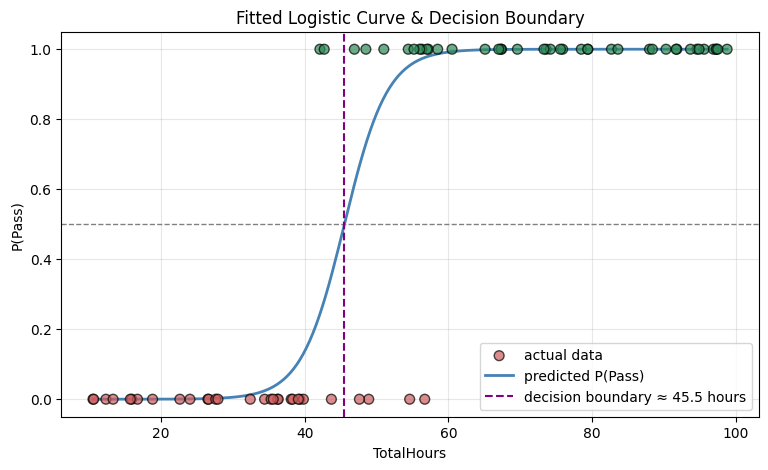

Decision boundary: students need roughly 45.5 total study hours before the model predicts Pass more likely than Fail.


In [15]:
hours_line = np.linspace(X.min(), X.max(), 200).reshape(-1, 1)
hours_line_scaled, _, _ = standardize_features(hours_line, mu, sigma)
hours_line_design = add_bias(hours_line_scaled)
proba_line = predict_proba(hours_line_design, theta)

# Decision boundary in original TotalHours units: where theta_0 + theta_1 * x_scaled = 0
boundary_scaled = -theta[0] / theta[1]
boundary_hours = boundary_scaled * sigma[0] + mu[0]

plt.figure(figsize=(9, 5))
plt.scatter(df['TotalHours'], df['Pass'], c=df['Pass'].map({0: 'indianred', 1: 'seagreen'}),
            s=50, alpha=0.7, edgecolor='k', label='actual data', zorder=3)
plt.plot(hours_line.ravel(), proba_line, color='steelblue', linewidth=2, label='predicted P(Pass)')
plt.axhline(0.5, color='gray', linestyle='--', linewidth=1)
plt.axvline(boundary_hours, color='purple', linestyle='--', linewidth=1.5,
            label=f'decision boundary ≈ {boundary_hours:.1f} hours')
plt.xlabel('TotalHours')
plt.ylabel('P(Pass)')
plt.title('Fitted Logistic Curve & Decision Boundary')
plt.legend()
plt.grid(alpha=0.3)
plt.show()

print(f"Decision boundary: students need roughly {boundary_hours:.1f} total study hours "
      f"before the model predicts Pass more likely than Fail.")

## 6. Evaluation

Confusion matrix, accuracy, precision, recall, and F1 - implemented from
scratch.

In [16]:
def confusion_matrix(y_true, y_pred):
    y_true, y_pred = np.asarray(y_true), np.asarray(y_pred)
    tp = np.sum((y_true == 1) & (y_pred == 1))
    tn = np.sum((y_true == 0) & (y_pred == 0))
    fp = np.sum((y_true == 0) & (y_pred == 1))
    fn = np.sum((y_true == 1) & (y_pred == 0))
    return tp, tn, fp, fn

def accuracy_score(y_true, y_pred):
    tp, tn, fp, fn = confusion_matrix(y_true, y_pred)
    return (tp + tn) / (tp + tn + fp + fn)

def precision_score(y_true, y_pred):
    tp, tn, fp, fn = confusion_matrix(y_true, y_pred)
    return tp / (tp + fp) if (tp + fp) > 0 else 0.0

def recall_score(y_true, y_pred):
    tp, tn, fp, fn = confusion_matrix(y_true, y_pred)
    return tp / (tp + fn) if (tp + fn) > 0 else 0.0

def f1_score(y_true, y_pred):
    p, r = precision_score(y_true, y_pred), recall_score(y_true, y_pred)
    return 2 * p * r / (p + r) if (p + r) > 0 else 0.0

In [17]:
y_pred_train = predict_class(X_train_design, theta, threshold=0.5)
y_pred_test = predict_class(X_test_design, theta, threshold=0.5)

for split_name, y_true, y_pred in [('train', y_train, y_pred_train), ('test', y_test, y_pred_test)]:
    tp, tn, fp, fn = confusion_matrix(y_true, y_pred)
    print(f"--- {split_name} (threshold = 0.5) ---")
    print(f"  Confusion matrix: TP={tp}  TN={tn}  FP={fp}  FN={fn}")
    print(f"  Accuracy:  {accuracy_score(y_true, y_pred):.4f}")
    print(f"  Precision: {precision_score(y_true, y_pred):.4f}")
    print(f"  Recall:    {recall_score(y_true, y_pred):.4f}")
    print(f"  F1-score:  {f1_score(y_true, y_pred):.4f}")
    print()

--- train (threshold = 0.5) ---
  Confusion matrix: TP=32  TN=22  FP=2  FN=2
  Accuracy:  0.9310
  Precision: 0.9412
  Recall:    0.9412
  F1-score:  0.9412

--- test (threshold = 0.5) ---
  Confusion matrix: TP=8  TN=4  FP=2  FN=0
  Accuracy:  0.8571
  Precision: 0.8000
  Recall:    1.0000
  F1-score:  0.8889



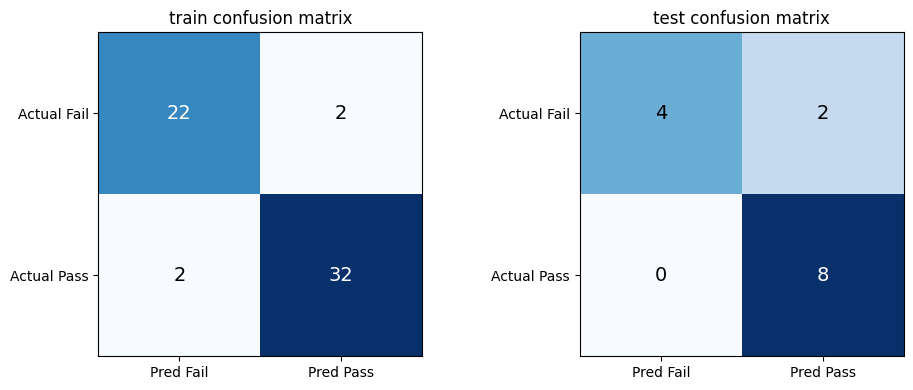

In [18]:
fig, axes = plt.subplots(1, 2, figsize=(10, 4))
for ax, split_name, y_true, y_pred in [
    (axes[0], 'train', y_train, y_pred_train),
    (axes[1], 'test', y_test, y_pred_test),
]:
    tp, tn, fp, fn = confusion_matrix(y_true, y_pred)
    matrix = np.array([[tn, fp], [fn, tp]])
    im = ax.imshow(matrix, cmap='Blues')
    for (i, j), val in np.ndenumerate(matrix):
        ax.text(j, i, str(val), ha='center', va='center', fontsize=14,
                color='white' if val > matrix.max() / 2 else 'black')
    ax.set_xticks([0, 1]); ax.set_xticklabels(['Pred Fail', 'Pred Pass'])
    ax.set_yticks([0, 1]); ax.set_yticklabels(['Actual Fail', 'Actual Pass'])
    ax.set_title(f"{split_name} confusion matrix")
plt.tight_layout()
plt.show()

## 7. Takeaways

- With only one feature, the decision boundary is just a single point on
  the `TotalHours` axis - everything to the right is predicted Pass,
  everything to the left is predicted Fail. That makes this a good,
  visual first example before the multi-feature model, where the
  boundary lives in 5-dimensional space and can't be plotted directly.
  
- Same six functions as before — `sigmoid`, `compute_logistic_cost`,
  `compute_logistic_gradients`, `logistic_gradient_descent`,
  `predict_proba`, `predict_class` — work unchanged whether there's 1
  feature or 5; only the shape of `X` (and therefore `theta`) changes.